In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
pd.set_option('display.width', 1000)
pd.read_csv('../stats-all-latest.csv').to_pickle('../stats-all-latest.pkl')

Total # of datapoints: 172555
Day 0 start:     1733097600000, 2024-12-02 00:00:00
First timestamp: 1733164858296, 2024-12-02 18:40:58.296000
Day 1 start:     1733184000000, 2024-12-03 00:00:00
Last timestamp:  1733650677649, 2024-12-08 09:37:57.649000
     day providerName  imageName outputFormat  providerMemoryAssociated  outputWidth    max  count  expected_count  missing_executions
7      5          aws  landscape         heif                      3538         1080   3620    286             288                   2
11     5          aws  landscape         jpeg                       885         1920   3563    286             288                   2
13     5          aws  landscape         jpeg                      1769         1080   1586    287             288                   1
16     5          aws  landscape         jpeg                      3538         1080   1490    281             288                   7
21     5          aws  landscape         webp                      1769  

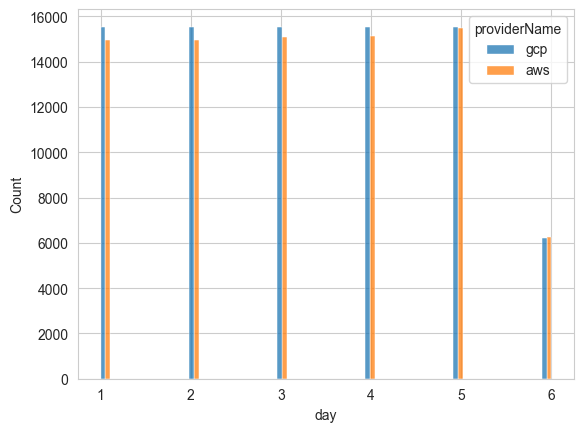

In [28]:
from datetime import datetime as dt
import seaborn as sns
df = pd.read_pickle('../stats-all-latest.pkl')
print(f'Total # of datapoints: {len(df)}')

millis_in_day = 1000 * 60 * 60 * 24

# First and last executions, timestamp is in millis
min_ts = df["timestamp"].min()
max_ts = df["timestamp"].max()
day_0 = min_ts - min_ts % millis_in_day
day_1 = day_0 + millis_in_day
print(f'Day 0 start:     {day_0}, {dt.fromtimestamp(day_0/1000)}')
print(f'First timestamp: {min_ts}, {dt.fromtimestamp(min_ts/1000)}')
print(f'Day 1 start:     {day_1}, {dt.fromtimestamp(day_1/1000)}')
print(f'Last timestamp:  {max_ts}, {dt.fromtimestamp(max_ts/1000)}')

# Drop measurements from day
df = df.loc[(df['timestamp'] > day_1)]

# Calculate day of week and hour of day
df['day'] = (df['timestamp'] - day_0) // millis_in_day
df['hour'] = (df['timestamp'] - day_0) // (millis_in_day / 24) % 24

# Count occurrences by day
# daily_counts = df.groupby('day').size().res('count')
daily_counts = df.loc[(df['day'] == 5)] \
    .groupby(['day', 'providerName', 'imageName', 'outputFormat', 'providerMemoryAssociated', 'outputWidth']) \
    .agg(max_processing_ms=('durationProcessingMs', 'max'), count=('timestamp', 'size')) \
    .reset_index()
daily_counts['expected_count'] = 24 * 12 # hours * executions * clouds * images * formats * widths * memory
daily_counts['missing_executions'] = daily_counts['expected_count'] - daily_counts['count']
daily_counts = daily_counts.loc[(daily_counts['missing_executions'] > 0)]
print(daily_counts)
sns.color_palette("colorblind")

# Create the countplot using seaborn
sns.despine(left=True)
sns.set_style("whitegrid")
sns.histplot(data=df, x='day', stat='count', hue="providerName", multiple='dodge', hue_order=['gcp', 'aws'], legend=True)

# Group by series columns
groups = df.groupby(['imageName','providerName', 'outputFormat', 'outputWidth', 'providerMemoryAssociated',  ])
print(f'Actual # of groups: {groups.ngroups}')

# Initialize a dictionary to store counts for each key
from collections import defaultdict  # Import defaultdict
key_counts = defaultdict(lambda: defaultdict(int))

for name, group in groups:
    # Extract individual values from the group name
    image_name, output_format, output_width, provider_memory, provider_name = name

    # Update counts for each key
    key_counts['imageName'][image_name] += 1
    key_counts['outputFormat'][output_format] += 1
    key_counts['outputWidth'][output_width] += 1
    key_counts['providerMemoryAssociated'][provider_memory] += 1
    key_counts['providerName'][provider_name] += 1

# Print the results
for key, values in key_counts.items():
    # print(f"\nUnique values for {key}:")
    for value, count in values.items():
        print(f"{key}/{value}: {count}")

In [65]:
# groups_frequency = groups.size().sort_values()
# print(groups_frequency.head(10).to_string())
# print('...')
# print(groups_frequency.tail(10).to_string())
